In [1]:
import math
import seaborn as sns
from dataclasses import dataclass
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


## Model Parameter

In [2]:
@dataclass
class ModelArgs:

    vocab_size : int = 2000
    seq_len : int = 10
    batch_size : int = 32
    d_model : int = 300
    n_heads : int = 2
    num_layers : int = 2
    hidden_dim : int = 768
    dropout : float = 0.5


args = ModelArgs()
input = torch.randint(0, args.vocab_size, (args.batch_size, args.seq_len))
print(f"Input : {input.shape}")

Input : torch.Size([32, 10])


## Input Embedding

In [3]:
class InputEmbedding(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.tok_emb = nn.Embedding(args.vocab_size, args.d_model)

    def forward(self, x):
        # (batch_size, seq_len) -> (batch_size, seq_len, d_model)
        return self.tok_emb(x)
    
# Exmaple
tok_embedding = InputEmbedding(args)
input_emb = tok_embedding(input)
print(input_emb.shape)  

torch.Size([32, 10, 300])


## Positional Embedding as Parameter

In [4]:
## PositionEmbedding as model parameter
class PositionEmbedding(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.pos_emb = nn.Embedding(args.seq_len, args.d_model)

    def forward(self, x):
        # x : (batch_size, seq_len, d_model) 

        # seq_len -> (seq_len, d_model)
        pos_emb = self.pos_emb(torch.arange(x.size(1)))
        # (seq_len, d_model) -> (1, seq_len, d_model)
        pos_emb = pos_emb.unsqueeze(0)

        # (batch_size, seq_len, d_model) + (1, seq_len, d_model) -> (batch_size, seq_len, d_model)
        return x + pos_emb

# Example
pos_embedding = PositionEmbedding(args)
pos_emb = pos_embedding(input_emb)
print(pos_emb.shape)  

torch.Size([32, 10, 300])


## Positional Embedding as Fixed

In [5]:
## PositionEmbedding as fixed
class PositionEmbedding(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()

        # pe : (seq_len, d_model)
        pe = torch.zeros(args.seq_len, args.d_model)
        # pos : (seq_len, 1)
        pos = torch.arange(0, args.seq_len).unsqueeze(1) 
        # div_term : (d_model/2)
        div_term = torch.exp(torch.arange(0, args.d_model, 2).float() * -(math.log(10000)) / args.d_model)

        # pe : (seq_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        # pe : (1, seq_len, d_model)
        pe = pe.unsqueeze(0)
        pe.requires_grad_(False)
        ## Register the buffer
        self.register_buffer('pe', pe)


    def forward(self, x):
        # x : (batch_size, seq_len, d_model)
        # pe : (1, seq_len, d_model)

        # (batch_size, seq_len, d_model) + (1, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x
    
# Example
pos_emb = PositionEmbedding(args)
pos_emb = pos_emb(input_emb)
print(pos_emb.shape)  

torch.Size([32, 10, 300])


## Layer Normalization

In [6]:
class LayerNorm(nn.Module):


    def __init__(self, args: ModelArgs, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(args.d_model)) ## multiply
        self.bias = nn.Parameter(torch.zeros(args.d_model)) ## add
    

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        x = (x - mean) / (std + self.eps)
        x = self.alpha * x + self.bias
        return x

# Example
layer_norm = LayerNorm(args)
layer_norm_out = layer_norm(pos_emb)
print(layer_norm_out.shape)


torch.Size([32, 10, 300])


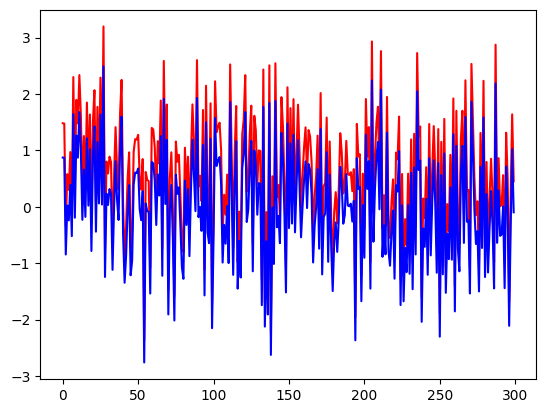

In [7]:
plt.plot(pos_emb.detach().numpy()[0][1], color = 'red')
plt.plot(layer_norm_out.detach().numpy()[0][1], color = 'blue')

del layer_norm_out, layer_norm

## MultiHead Attention

In [8]:
class MultiHeadAttentionBlock(nn.Module):

    def __init__(self, args):
        super().__init__()

        self.d_model = args.d_model
        self.n_heads = args.n_heads

        assert self.d_model % self.n_heads == 0, "d_model should be divisible by n_heads"

        self.head_dim = args.d_model // args.n_heads
        self.w_q = nn.Linear(self.d_model, self.head_dim)
        self.w_k = nn.Linear(self.d_model, self.head_dim)
        self.w_v = nn.Linear(self.d_model, self.head_dim)
        self.w_o  = nn.Linear(self.d_model, self.d_model)

    @staticmethod
    def attention(q,k,v, mask = None):
        # q, k, v : (batch_size, seq_len, d_model)

        # (batch_size, seq_len, d_model) * (batch_size, d_model, seq_len) => (batch_size, seq_len, seq_len) 
        d_k = k.size(-1)
        scaled_dot_product = (q @ k.transpose(-1,-2)) / math.sqrt(d_k)

        if mask is not None:
            scaled_dot_product.masked_fill_(mask, -torch.inf)

        ## (batch_size, seq_len, seq_len) 
        attention_score = F.softmax(scaled_dot_product, dim=-1)

        ## (batch_size, seq_len, seq_len) * (batch_size, seq_len, d_model) => (batch_size, seq_len, d_model)
        contextual_emb = attention_score @ v

        return contextual_emb, attention_score

    
    def forward(self, q,k, v, mask = None):
        # q, k, v : (batch_size, seq_len, head_dim)
        q = self.w_q(q)
        k = self.w_k(k)
        v = self.w_v(v)

        # (batch_size, seq_len, head_dim) => (batch_size, seq_len, d_model)
        scores = [MultiHeadAttentionBlock.attention(q,k,v, mask) for _ in range(self.n_heads)]
        contextual_emb = torch.cat([score[0] for score in scores], dim=-1)
        self.attention_scores = [score[1] for score in scores]

        ## Output layer
        contextual_emb = self.w_o(contextual_emb)

        return contextual_emb
    

# Example 
multi_head_attention_block = MultiHeadAttentionBlock(args)
multi_head_attention_block_out = multi_head_attention_block(pos_emb,pos_emb,pos_emb)
print(multi_head_attention_block_out.shape)  # (batch_size, seq_len, d_model)

del multi_head_attention_block_out

torch.Size([32, 10, 300])


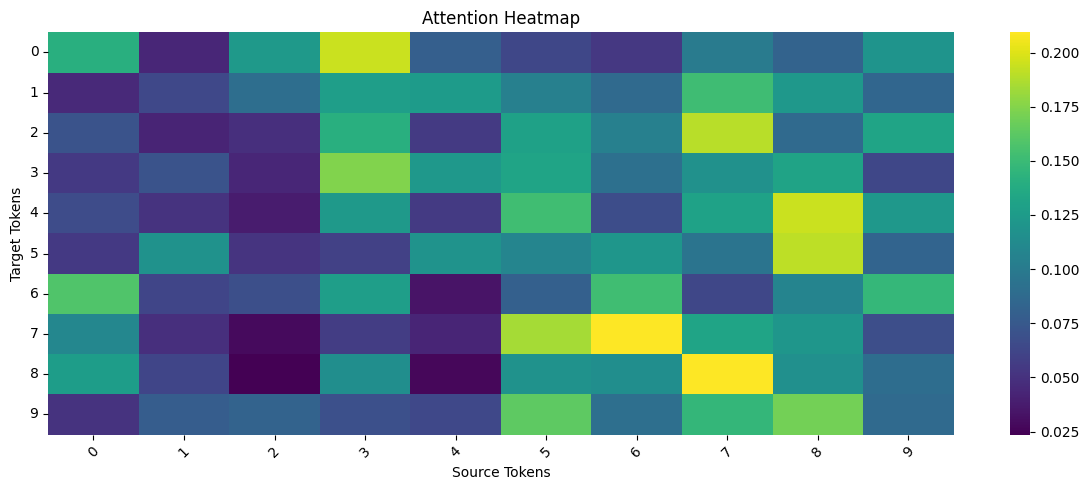

In [9]:
## Pick one layer
layer = 0
layer_attention = multi_head_attention_block.attention_scores[layer].detach().numpy()
## Pick one head
sample_index = 0
sample_attention = layer_attention[sample_index]

# Plotting the attention scores
plt.figure(figsize=(12, 5))
sns.heatmap(sample_attention,  cmap='viridis', cbar=True)
plt.title("Attention Heatmap")
plt.xlabel("Source Tokens")
plt.ylabel("Target Tokens")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

del layer_attention, sample_attention

## MultiHead Attention - Optimized Implementation

In [10]:
class MultiHeadAttentionBlock(nn.Module):

    def __init__(self, args):
        super().__init__()

        self.d_model = args.d_model
        self.n_heads = args.n_heads

        assert self.d_model % self.n_heads == 0, "d_model should be divisible by n_heads"

        
        self.head_dim = args.d_model // args.n_heads
        self.w_q = nn.Linear(self.d_model, self.d_model)
        self.w_k = nn.Linear(self.d_model, self.d_model)
        self.w_v = nn.Linear(self.d_model, self.d_model)
        self.w_o = nn.Linear(self.d_model, self.d_model)


    @staticmethod
    def attention(q,k,v, mask = None):
        # q, k, v : (batch_size, seq_len, d_model)

        # (batch_size, seq_len, d_model) * (batch_size, d_model, seq_len) => (batch_size, seq_len, seq_len) 
        d_k = k.size(-1)
        scaled_dot_product = (q @ k.transpose(-1,-2)) / math.sqrt(d_k)

        if mask is not None:
            scaled_dot_product.masked_fill_(mask, -torch.inf)

        ## (batch_size, seq_len, seq_len) 
        attention_score = F.softmax(scaled_dot_product, dim=-1)

        ## (batch_size, seq_len, seq_len) * (batch_size, seq_len, d_model) => (batch_size, seq_len, d_model)
        contextual_emb = attention_score @ v

        return contextual_emb, attention_score



    def forward(self, q,k,v, mask=None):
        # q, k, v : (batch_size, seq_len, d_model)
        q = self.w_q(q)
        k = self.w_k(k)
        v = self.w_v(v)

        # (batch_size, seq_len, d_model) => (batch_size, seq_len, n_heads, head_dim)
        q = q.reshape(q.shape[0], q.shape[1], self.n_heads, self.head_dim)
        k = k.reshape(q.shape[0], q.shape[1], self.n_heads, self.head_dim)
        v = v.reshape(q.shape[0], q.shape[1], self.n_heads, self.head_dim)

        contextual_emb, self.attention_score = MultiHeadAttentionBlock.attention(q,k,v, mask)

        # (batch_size, seq_len, n_heads, head_dim) => (batch_size, seq_len, d_model)
        contextual_emb = contextual_emb.reshape(contextual_emb.shape[0], contextual_emb.shape[1],-1)

        ## Output layer
        contextual_emb = self.w_o(contextual_emb)
        return contextual_emb
    

# Example 
multi_head_attention_block = MultiHeadAttentionBlock(args)
multi_head_attention_block_out = multi_head_attention_block(pos_emb,pos_emb,pos_emb)
print(multi_head_attention_block_out.shape) 

del multi_head_attention_block_out

torch.Size([32, 10, 300])


## Residual Block

In [11]:
class ResidualBlock(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.layer_norm = LayerNorm(args)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, sublayer):
        # x : (batch_size, seq_len, d_model)
        # sublayer : (batch_size, seq_len, d_model)
        return x + self.dropout(self.layer_norm(sublayer(x)))
    
# Example
residual_block = ResidualBlock(args)
residual_block_out = residual_block(pos_emb, lambda x: multi_head_attention_block(x,x,x, mask = None))
print(residual_block_out.shape)  # (batch_size, seq_len, d_model)

torch.Size([32, 10, 300])



## FeedForward Block

In [12]:
class FeedForwardBlock(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.linear1 = nn.Linear(args.d_model, args.hidden_dim)
        self.linear2 = nn.Linear(args.hidden_dim, args.d_model)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x):
        # x : (batch_size, seq_len, d_model)
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

# Example
feed_forward_block = FeedForwardBlock(args)
feed_forward_block_out = feed_forward_block(residual_block_out)
print(feed_forward_block_out.shape)  # (batch_size, seq_len, d_model)

del feed_forward_block_out, residual_block_out

torch.Size([32, 10, 300])


## Encoder Block

In [13]:
class EncoderBlock(nn.Module):

    def __init__(self, args):
        super().__init__()

        self.multi_head_attention_block = MultiHeadAttentionBlock(args)
        self.feed_forward_block = FeedForwardBlock(args)
        self.residual_block =  nn.ModuleList([ResidualBlock(args) for i in range(2)])

    def forward(self, x, mask):
        # x : (batch_size, seq_len, d_model)
        x = self.residual_block[0](x, lambda x: self.multi_head_attention_block(x,x,x, mask))
        x = self.residual_block[1](x, lambda x: self.feed_forward_block(x))
        return x
    

# Example
encoder_block = EncoderBlock(args)
encoder_block_out = encoder_block(pos_emb, mask = None)
print(encoder_block_out.shape)

del encoder_block_out

torch.Size([32, 10, 300])


## Encoder 

In [14]:
class Encoder(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(args) for _ in range(args.num_layers)])
        self.layer_norm = LayerNorm(args)

    def forward(self, x, mask):
        # x : (batch_size, seq_len, d_model)
        for layer in self.layers:
            x = layer(x, mask)
        return self.layer_norm(x)


# Example
encoder = Encoder(args)
encoder_out = encoder(pos_emb, mask = None)
print(encoder_out.shape)  # (batch_size, seq_len, d_model)

# del encoder_out

torch.Size([32, 10, 300])


## Decoder Block

In [15]:
class DecoderBlock(nn.Module):

    def __init__(self, args):
        super().__init__()

        self.masked_attention_block = MultiHeadAttentionBlock(args)
        self.cross_attention_block = MultiHeadAttentionBlock(args)
        self.feed_forward_block = FeedForwardBlock(args)
        self.residual_block = nn.ModuleList([ResidualBlock(args) for i in range(3)])
        self.layer_norm = LayerNorm(args)


    def forward(self, x, encoder_out, src_mask, tgt_mask):
        # x : (batch_size, seq_len, d_model)
        # encoder_out : (batch_size, seq_len, d_model)
        x = self.residual_block[0](x, lambda x: self.masked_attention_block(x, x, x, tgt_mask))
        x = self.residual_block[1](x, lambda x: self.cross_attention_block(x, encoder_out, encoder_out, src_mask))
        x = self.residual_block[2](x, lambda x: self.feed_forward_block(x))
        return self.layer_norm(x)
       
    
# Example
decoder_block = DecoderBlock(args)
decoder_block_out = decoder_block(pos_emb, encoder_out, src_mask = None, tgt_mask = None)
print(decoder_block_out.shape)  # (batch_size, seq_len, d_model)

del decoder_block_out


torch.Size([32, 10, 300])


## Decoder

In [18]:
class Decoder(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.layers = nn.ModuleList([DecoderBlock(args) for _ in range(args.num_layers)])
        self.layer_norm = LayerNorm(args)

    def forward(self, x, encoder_out, src_mask, tgt_mask):
        # x : (batch_size, seq_len, d_model)
        for layer in self.layers:
            x = layer(x, encoder_out, src_mask, tgt_mask)
        return self.layer_norm(x)
    
# Example
decoder = Decoder(args)
decoder_out = decoder(pos_emb, encoder_out, src_mask = None, tgt_mask = None)
print(decoder_out.shape) 

torch.Size([32, 10, 300])


## Projection Layer

In [19]:
class ProjectLayer(nn.Module):

    def __init__(self, args) -> None:
        super().__init__()
        self.proj = nn.Linear(args.d_model, args.vocab_size)

    def forward(self, x):
        ## (batch, seq_len, d_model) --> (batch, seq_len, vocab_size)
        return self.proj(x)
    
# Example
project_layer = ProjectLayer(args)
project_layer_out = project_layer(decoder_out)
print(project_layer_out.shape)  # (batch_size, seq_len, vocab_size)

torch.Size([32, 10, 2000])


## Transormer

In [ ]:
class Transformer(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.input_embedding = InputEmbedding(args)
        self.position_embedding = PositionEmbedding(args)
        self.encoder = Encoder(args)
        self.decoder = Decoder(args)
        self.project_layer = ProjectLayer(args)

    def forward(self, x, src_mask, tgt_mask):
        # x : (batch_size, seq_len)
        x = self.input_embedding(x)
        x = self.position_embedding(x)
        encoder_out = self.encoder(x, mask = src_mask)
        decoder_out = self.decoder(x, encoder_out, src_mask, tgt_mask)
        out = self.project_layer(decoder_out)
        return out
    


# Example
transformer = Transformer(args)
transformer_out = transformer(input, src_mask = None, tgt_mask = None)
print(transformer_out.shape)  # (batch_size, seq_len, vocab_size)
del transformer_out

torch.Size([32, 10, 2000])
